<a href="https://colab.research.google.com/github/ARCHITTOMAR15/Sarcasm-Detection-with-Traditional-NLP-Deep-Learning-and-Transformers/blob/main/SARCSAM_DETECTION_USING_TRANSFORMER_MODELS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
os.listdir('/content/drive/MyDrive/sarcsam_detection')

['Sarcasm_Headlines_Dataset_v2.json']

In [3]:
# import all necessary libraries
import re
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline


In [4]:
#data reading
df=pd.read_json('/content/drive/MyDrive/sarcsam_detection/Sarcasm_Headlines_Dataset_v2.json',lines=True)

In [5]:
df.head()

,is_sarcastic,headline,article_link
0,1,thirtysomething scientists unveil doomsday clo...,https://www.theonion.com/thirtysomething-scien...
1,0,dem rep. totally nails why congress is falling...,https://www.huffingtonpost.com/entry/donna-edw...
2,0,eat your veggies: 9 deliciously different recipes,https://www.huffingtonpost.com/entry/eat-your-...
3,1,inclement weather prevents liar from getting t...,https://local.theonion.com/inclement-weather-p...
4,1,mother comes pretty close to using word 'strea...,https://www.theonion.com/mother-comes-pretty-c...


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28619 entries, 0 to 28618
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   is_sarcastic  28619 non-null  int64 
 1   headline      28619 non-null  object
 2   article_link  28619 non-null  object
dtypes: int64(1), object(2)
memory usage: 670.9+ KB


In [7]:
df.isnull().sum()

,0
is_sarcastic,0
headline,0
article_link,0


In [8]:
df.duplicated().sum()

np.int64(2)

In [9]:
df["headline"].duplicated().sum()

np.int64(116)

In [10]:
df=df.drop_duplicates(subset=["headline"]).reset_index(drop=True)

In [11]:
df["headline"].duplicated().sum()

np.int64(0)

In [12]:
# Basic minimal clearning
def clean_text(text):
  text=str(text)
  # remove URLs
  text = re.sub(r"http\S+|www\S+", "", text)
  # remove extra spaces
  text = re.sub(r"\s+", " ", text)

  return text.strip()

In [13]:
df["clean_headline"]=df["headline"].apply(clean_text)

In [14]:
df["is_sarcastic"].value_counts()

,count
is_sarcastic,
0,14951
1,13552


In [15]:
df["is_sarcastic"].value_counts(normalize=True)

,proportion
is_sarcastic,
0,0.524541
1,0.475459


In [16]:
#       Create train,test and validation slpit

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
train_df,temp_df=train_test_split(df,test_size=0.20,random_state=42,stratify=df["is_sarcastic"])

In [19]:
# split temp_df into test and validation
val_df,test_df=train_test_split(temp_df,test_size=0.50,random_state=42,stratify=temp_df["is_sarcastic"])

In [20]:
#reset index
train_df=train_df.reset_index(drop=True)
test_df=test_df.reset_index(drop=True)
val_df=val_df.reset_index(drop=True)

In [21]:
print("Train_shape",train_df.shape)
print("Test_shape",test_df.shape)
print("val_shape",val_df.shape)

Train_shape (22802, 4)
Test_shape (2851, 4)
val_shape (2850, 4)


In [22]:
# convert pandas dataframe to hugging face dataset
from datasets import Dataset

In [23]:
train_dataset=Dataset.from_pandas(train_df[["clean_headline","is_sarcastic"]])
test_dataset=Dataset.from_pandas(test_df[["clean_headline","is_sarcastic"]])
val_dataset=Dataset.from_pandas(val_df[["clean_headline","is_sarcastic"]])

In [24]:
# rename is_sarcastc to label
train_dataset=train_dataset.rename_column("is_sarcastic","label")
test_dataset=test_dataset.rename_column("is_sarcastic","label")
val_dataset=val_dataset.rename_column("is_sarcastic","label")

In [25]:
## BERT MODEL PRE REQUISITE

In [26]:
#### IMPORTING TOKENIZER
from transformers import DistilBertTokenizerFast
tokenizer=DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

In [27]:
print(tokenizer)

DistilBertTokenizer(name_or_path='distilbert-base-uncased', vocab_size=30522, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})


In [28]:
# Tokenise the Entire Data set (Train,test,validation data set) create a function

def tokenize(batch):
  return tokenizer(batch["clean_headline"],padding='max_length',truncation=True,max_length=128)


In [29]:
train_dataset =train_dataset.map(tokenize,batched=True)
test_dataset=test_dataset.map(tokenize,batched=True)
val_dataset=val_dataset.map(tokenize,batched=True)

Map:   0%|          | 0/22802 [00:00<?, ? examples/s]

Map:   0%|          | 0/2851 [00:00<?, ? examples/s]

Map:   0%|          | 0/2850 [00:00<?, ? examples/s]

In [30]:
print(train_dataset[0])

{'clean_headline': "'gobbler games' is the brutal hunger games parody you need to see", 'label': 0, 'input_ids': [101, 1005, 2175, 11362, 2099, 2399, 1005, 2003, 1996, 12077, 9012, 2399, 12354, 2017, 2342, 2000, 2156, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]}


In [31]:
#  Convert to PYtorch Format for Batch used in Training
train_dataset.set_format('torch',columns=['input_ids','attention_mask','label'])
test_dataset.set_format('torch',columns=['input_ids','attention_mask','label'])
val_dataset.set_format('torch',columns=['input_ids','attention_mask','label'])

In [32]:
# Create Data loaders
BATCH_SIZE=16
from torch.utils.data import DataLoader
train_loader=DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=BATCH_SIZE,shuffle=False)
val_loader=DataLoader(val_dataset,batch_size=BATCH_SIZE,shuffle=False)

In [33]:
batch=next(iter(train_loader))
print(batch.keys())

dict_keys(['label', 'input_ids', 'attention_mask'])


In [34]:
# LOAD PRETRAINED DISTILBERT MODEL

In [35]:
from transformers import DistilBertModel
distilbert=DistilBertModel.from_pretrained("distilbert-base-uncased")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [36]:
# PART 2

In [37]:
## FREEZE THE ORIZINAL DISTILBERT PARAMETERS
for param in distilbert.parameters():
  param.requires_grad=False

In [38]:
print(distilbert)

DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSelfAttention(
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=Tru

In [39]:
## Making own classififer head
import torch
import torch.nn as nn

In [40]:
class DistilBERTClassifier(nn.Module):

    def __init__(self, distilbert):

        super().__init__()

        self.distilbert = distilbert

        self.dropout = nn.Dropout(0.3)

        self.classifier = nn.Linear(768, 2)

    def forward(self, input_ids, attention_mask):

        outputs = self.distilbert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        cls_embedding = outputs.last_hidden_state[:, 0]

        x = self.dropout(cls_embedding)

        logits = self.classifier(x)

        return logits

In [41]:
model = DistilBERTClassifier(distilbert)

In [42]:
#Defining the loss function

In [43]:
criterion=nn.CrossEntropyLoss()

In [44]:
#optimizer and schedular

In [45]:
from torch.optim import AdamW

In [46]:
optimizer=AdamW(model.parameters(),lr=0.0002)

In [47]:
from transformers import get_linear_schedule_with_warmup

In [48]:
EPOCHS=5
total_training_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=total_training_steps
)

In [49]:
## PART - 3

In [50]:
## CREATE TRAINING LOOP

In [51]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

print(device)

cuda


In [52]:
train_losses = []
train_accuracies = []

for epoch in range(EPOCHS):

    # -----------------------------
    # Training Mode
    # -----------------------------
    model.train()

    running_loss = 0
    correct_predictions = 0
    total_examples = 0

    # Iterate over batches
    for batch in train_loader:

        # Move tensors to GPU
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        logits = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # Compute loss
        loss = criterion(logits, labels)

        # Backpropagation
        loss.backward()

        # Update trainable parameters
        optimizer.step()

        # Update learning rate
        scheduler.step()

        # Store batch loss
        running_loss += loss.item()

        # Predictions
        predictions = torch.argmax(logits, dim=1)

        # Count correct predictions
        correct_predictions += (predictions == labels).sum().item()

        # Total samples
        total_examples += labels.size(0)

    # Epoch statistics
    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = correct_predictions / total_examples

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Training Loss : {epoch_loss:.4f}")
    print(f"Training Accuracy : {epoch_accuracy:.4f}")

Epoch 1/5
Training Loss : 0.5445
Training Accuracy : 0.7491
Epoch 2/5
Training Loss : 0.4750
Training Accuracy : 0.7903
Epoch 3/5
Training Loss : 0.4587
Training Accuracy : 0.7984
Epoch 4/5
Training Loss : 0.4504
Training Accuracy : 0.8026
Epoch 5/5
Training Loss : 0.4478
Training Accuracy : 0.8062


In [53]:
## Validation CODE

In [54]:
val_losses = []
val_accuracies = []

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0
    correct_predictions = 0
    total_examples = 0

    # -----------------------------
    # TRAINING
    # -----------------------------
    for batch in train_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()

        logits = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        loss = criterion(logits, labels)

        loss.backward()

        optimizer.step()

        scheduler.step()

        running_loss += loss.item()

        predictions = torch.argmax(logits, dim=1)

        correct_predictions += (predictions == labels).sum().item()

        total_examples += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_accuracy = correct_predictions / total_examples

    # -----------------------------
    # VALIDATION
    # -----------------------------
    model.eval()

    running_val_loss = 0
    correct_predictions = 0
    total_examples = 0

    with torch.no_grad():

        for batch in val_loader:

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            logits = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            loss = criterion(logits, labels)

            running_val_loss += loss.item()

            predictions = torch.argmax(logits, dim=1)

            correct_predictions += (predictions == labels).sum().item()

            total_examples += labels.size(0)

    val_loss = running_val_loss / len(val_loader)
    val_accuracy = correct_predictions / total_examples

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print("-"*50)
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss      : {train_loss:.4f}")
    print(f"Train Accuracy  : {train_accuracy:.4f}")
    print(f"Validation Loss : {val_loss:.4f}")
    print(f"Validation Acc. : {val_accuracy:.4f}")

--------------------------------------------------
Epoch 1/5
Train Loss      : 0.4448
Train Accuracy  : 0.8050
Validation Loss : 0.4207
Validation Acc. : 0.8221
--------------------------------------------------
Epoch 2/5
Train Loss      : 0.4440
Train Accuracy  : 0.8046
Validation Loss : 0.4207
Validation Acc. : 0.8221
--------------------------------------------------
Epoch 3/5
Train Loss      : 0.4452
Train Accuracy  : 0.8045
Validation Loss : 0.4207
Validation Acc. : 0.8221
--------------------------------------------------
Epoch 4/5
Train Loss      : 0.4454
Train Accuracy  : 0.8058
Validation Loss : 0.4207
Validation Acc. : 0.8221
--------------------------------------------------
Epoch 5/5
Train Loss      : 0.4458
Train Accuracy  : 0.8070
Validation Loss : 0.4207
Validation Acc. : 0.8221


In [55]:
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

In [56]:
model.eval()

test_loss = 0

all_labels = []
all_predictions = []
all_probabilities = []

with torch.no_grad():

    for batch in test_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        logits = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        loss = criterion(logits, labels)

        test_loss += loss.item()

        probabilities = torch.softmax(logits, dim=1)

        predictions = torch.argmax(probabilities, dim=1)

        all_labels.extend(labels.cpu().numpy())

        all_predictions.extend(predictions.cpu().numpy())

        all_probabilities.extend(
            probabilities[:,1].cpu().numpy()
        )

test_loss = test_loss / len(test_loader)

print(f"Test Loss : {test_loss:.4f}")

Test Loss : 0.4237


In [57]:
accuracy = accuracy_score(
    all_labels,
    all_predictions
)

In [58]:
precision = precision_score(
    all_labels,
    all_predictions
)

In [59]:
recall = recall_score(
    all_labels,
    all_predictions
)

In [60]:
f1 = f1_score(
    all_labels,
    all_predictions
)

In [61]:
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Accuracy  : 0.8169
Precision : 0.8268
Recall    : 0.7780
F1 Score  : 0.8017


In [62]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

print(cm)

[[1274  221]
 [ 301 1055]]


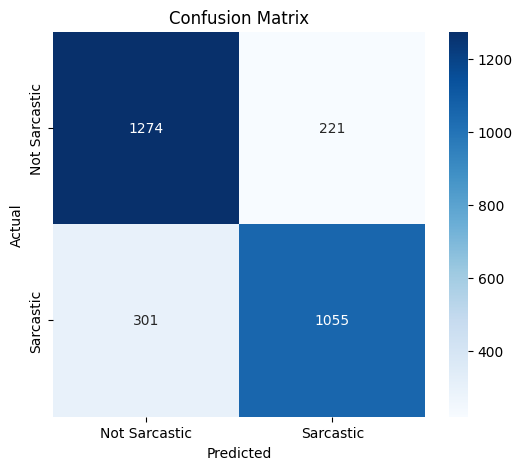

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Sarcastic","Sarcastic"],
    yticklabels=["Not Sarcastic","Sarcastic"]
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [64]:
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=[
            "Not Sarcastic",
            "Sarcastic"
        ]
    )
)

               precision    recall  f1-score   support

Not Sarcastic       0.81      0.85      0.83      1495
    Sarcastic       0.83      0.78      0.80      1356

     accuracy                           0.82      2851
    macro avg       0.82      0.82      0.82      2851
 weighted avg       0.82      0.82      0.82      2851



In [65]:
auc = roc_auc_score(
    all_labels,
    all_probabilities
)

print(f"ROC AUC : {auc:.4f}")

ROC AUC : 0.8951


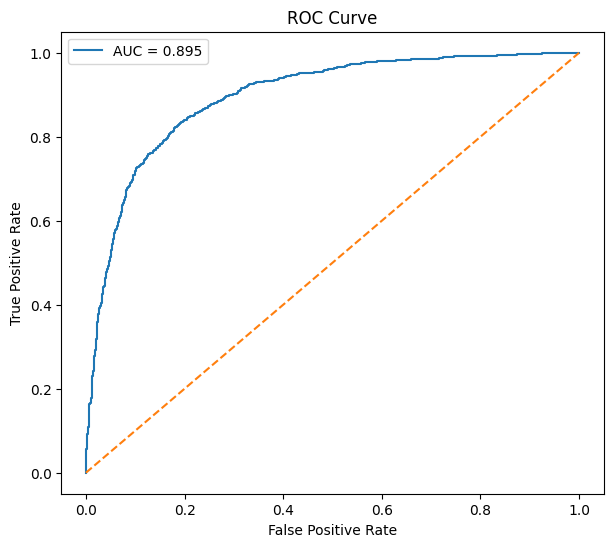

In [66]:
fpr, tpr, thresholds = roc_curve(
    all_labels,
    all_probabilities
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

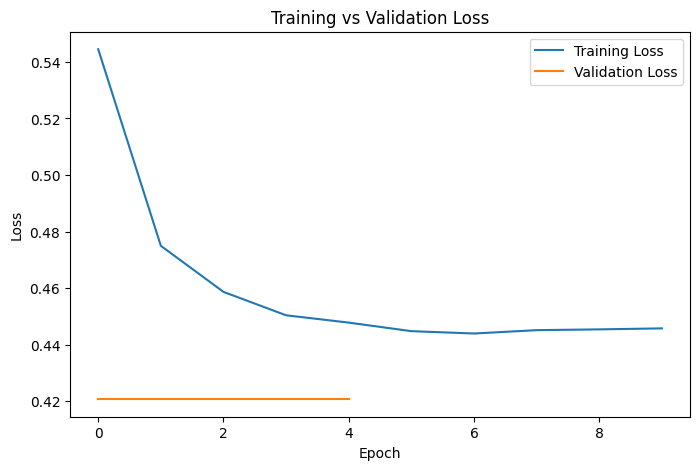

In [67]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Training Loss")

plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

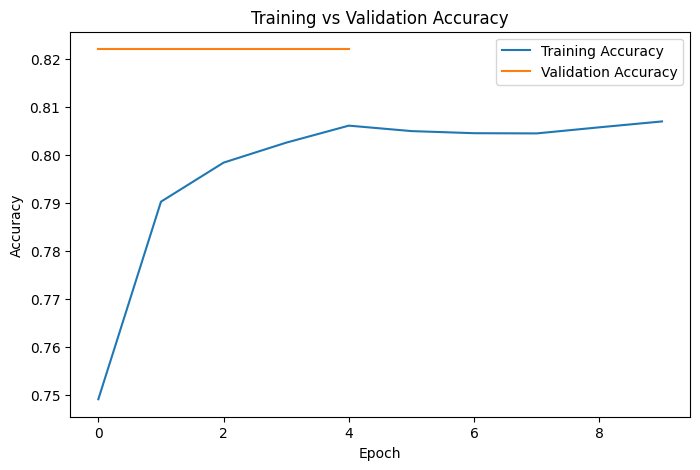

In [68]:
plt.figure(figsize=(8,5))

plt.plot(
    train_accuracies,
    label="Training Accuracy"
)

plt.plot(
    val_accuracies,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.show()